In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from datetime import date

In [3]:
def load_data():
    df = pd.read_csv('./HGSOC/ov2295_snv_counts.csv')
    df = df.astype({'chrom': 'str', 
                    'coord': 'int32', 
                    'ref': 'str',
                    'alt': 'str',
                    'ref_counts': 'int32',
                    'alt_counts': 'int32'})
    df['snp_id'] = df['chrom'] + ':' + df['coord'].astype(str) + ':' + df['ref'] + ':' + df['alt']
    df_clones = pd.read_csv('./HGSOC/ov2295_clone_clusters.csv')
    filtered_cells = df_clones['cell_id'].unique()
    df = df[df['cell_id'].isin(filtered_cells)]

    # filter out non-informative sites, criterion: more than 650 cells missed
    informative_df = df.groupby('snp_id').size().sort_values(ascending=False)
    informative_sites = informative_df[informative_df > len(filtered_cells) - 650].index.tolist()
    df = df[df['snp_id'].isin(informative_sites)]
    df_cell_cn = pd.read_csv('./HGSOC/ov2295_cell_cn.csv')

    df_all = pd.read_csv('./HGSOC/variants_with_cnv_state.csv')
    df_all['snp_id'] = df_all.apply(lambda x: f"{x['chrom']}:{x['coord']}:{x['ref']}:{x['alt']}", axis=1)
    df_all = df_all[df_all['snp_id'].isin(informative_sites)]
    return df_all, df_clones, df_cell_cn, df


def sample_cells(df, n_sample=200):
    df = df.sample(n_sample)
    print(df.groupby('clone_id').count())
    return df 

def filter_cell_and_site(df, df_sample):
    filtered_cells = df_sample['cell_id'].unique()
    df = df[df['cell_id'].isin(filtered_cells)]
    informative_df = df.groupby('snp_id').size().sort_values(ascending=False)
    informative_sites = informative_df[informative_df > len(filtered_cells) * 0.25].index.tolist()
    df = df[df['snp_id'].isin(informative_sites)]
    return df


def to_scistreecna_input(df):
    refs = df.pivot(index='snp_id', columns='cell_id', values='ref_counts').values
    alts = df.pivot(index='snp_id', columns='cell_id', values='alt_counts').values
    copies = df.pivot(index='snp_id', columns='cell_id', values='state').values
    refs = np.nan_to_num(refs, nan=0)
    alts = np.nan_to_num(alts, nan=0)
    copies = np.nan_to_num(copies, nan=-1)
    data = np.concat([refs[..., np.newaxis], alts[..., np.newaxis], copies[..., np.newaxis]], axis=-1)
    return data


In [3]:
df_all, df_clones, df_cell_cn, df = load_data()

sample_size = 200
df_subsample = sample_cells(df_clones, sample_size)

/tmp/ipykernel_3299803/3263996260.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./HGSOC/ov2295_snv_counts.csv')
/tmp/ipykernel_3299803/3263996260.py:20: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv('./HGSOC/variants_with_cnv_state.csv')


          cell_id
clone_id         
0              36
1              23
6              16
8              26
10             23
11             22
14             23
16             13
17             18


In [4]:
df_all_subsample = filter_cell_and_site(df_all, df_subsample)
scistreecna_input = to_scistreecna_input(df_all_subsample)

In [2]:
import os
import numpy as np 
import pandas as pd 
import popgen
from scistree_cna import *
from copy_number_tree_builder import construct_nj_tree_with_biopython
import scistree2 as s2
from other_tools import run_cellphy_reads
from simulation_custom import simulate
## 
from sklearn.metrics.pairwise import cosine_similarity
import pickle


def run_copy_num_nj(reads):
    copy_number_tree = construct_nj_tree_with_biopython(reads[:, :, 2])
    copy_number_tree = popgen.utils.from_newick(copy_number_tree)
    return copy_number_tree


def run_dice(reads):
    output_to_dice(reads)
    PATH = '/home/haz19024/miniconda3/envs/scistree2/bin/'
    os.system(f'PATH={PATH} dice -i dice_input.tsv -t -o dice_output -m balME')
    with open(f'dice_output/standard_root_balME_tree.nwk', 'r') as f:
        dice_nwk = f.readline().strip()
    dice_tree = popgen.utils.from_newick(dice_nwk)
    n_cell = len(dice_tree.get_leaves())
    dice_name_map = {f'leaf{i}': str(i) for i in range(n_cell)}
    dice_tree = popgen.utils.relabel(dice_tree, name_map=dice_name_map)
    return dice_tree


def run_cellphy(reads):
    cellphy_tree = run_cellphy_reads(reads)
    # cellphy_geno = get_cellphy_genotype('cellphy_tmp', tg)
    return cellphy_tree


def run_scistree2(reads):
    n_cell = reads.shape[1]
    gp = s2.probability.from_reads(reads[:, :, :2], cell_names=[f'{i}' for i in range(n_cell)], posterior=False)
    caller_spr = s2.ScisTree2(threads=8)
    tree_spr, imputed_genotype_spr, likelihood_spr = caller_spr.infer(gp)
    return tree_spr, imputed_genotype_spr.values


def run_scistree2_nj(reads):
    n_cell = reads.shape[1]
    gp = s2.probability.from_reads(reads[:, :, :2], cell_names=[f'{i}' for i in range(n_cell)], posterior=False)
    caller_spr = s2.ScisTree2(threads=8, nj=True)
    tree_spr, imputed_genotype_spr, likelihood_spr = caller_spr.infer(gp)
    return tree_spr, imputed_genotype_spr.values


def run_scistreec(reads, tree):
    n_site, n_cell, _ = reads.shape
    # cn_avg = estimate_copy_number(reads[:, :, -1], tree)
    s = ScisTreeC(CN_MAX=9, CN_MIN=1, LAMBDA_C=100, LAMBDA_S=1, LAMBDA_T=2*n_cell-1, verbose=False)
    probs = s.init_prob_leaves_gpu(reads, cnerr=0.05, af=0.5)
    ctree, ml = s.local_search_batch(probs, tree, tree_batch_size=8)
    ml2, indices = s.marginal_evaluate_dp(probs, ctree)
    scistreec_geno = construct_genotype(ctree, indices)
    # sites = [_ for _ in range(n_site)]
    # decoded_trees = s.viterbi_decoding(probs, ctree, sites)
    # tt = find_copy_gain_loss_on_branch(decoded_trees) 
    return ctree, scistreec_geno


def find_copy_gain_loss_on_branch(decoded_trees, gene_names=None):
    if gene_names is None:
        gene_names = [f'gene_{i}' for i in range(len(decoded_trees))]
    traversor = popgen.utils.TraversalGenerator()
    tree = decoded_trees[0].copy() # a fresh tree
    for node in traversor(tree):
        node.events = {'loss': [], 'gain': []}
    for d_tree, gene_name in zip(decoded_trees, gene_names):
        for node in traversor(d_tree):
            if node.is_root():
                if node.cn[1] != 0:
                    tree[node.name].events['gain'].append(f'{gene_name}:({node.cn[0]}: {node.cn[1]})')
            else:
                if node.cn[1] > node.parent.cn[1]:
                    tree[node.name].events['gain'].append(f'{gene_name}:({node.cn[0]}: {node.cn[1]})')
                if node.cn[1] < node.parent.cn[1] and node.cn[1] == 0:
                    tree[node.name].events['loss'].append(f'{gene_name}:({node.cn[0]}: {node.cn[1]})')
    return tree


tskit not found.
tskit not found.


In [6]:
scistree2_tree, scistree2_geno = run_scistree2(scistreecna_input)

scistreec_tree, scistreec_geno = run_scistreec(scistreecna_input, scistree2_tree) 

xxx [[-1. -1. -1. ...  4. -1. -1.]
 [-1. -1. -1. ... -1.  4. -1.]
 [-1. -1. -1. ... -1. -1. -1.]
 ...
 [ 2. -1. -1. ... -1.  9. 11.]
 [-1. -1. -1. ... -1. -1. -1.]
 [-1. -1. -1. ...  7. -1. -1.]]
new tree evaluated -90102.08151626587 new tree evaluated -89957.14396286011 new tree evaluated -89779.23274993896 new tree evaluated -89670.08870697021 new tree evaluated -89563.84708786011 new tree evaluated -89466.14882278442 new tree evaluated -89380.98217773438 new tree evaluated -89303.05507659912 new tree evaluated -89237.42255401611 new tree evaluated -89175.47792053223 new tree evaluated -89107.1457862854 new tree evaluated -89052.35749816895 new tree evaluated -88987.196559906 new tree evaluated -88931.3787689209 new tree evaluated -88870.44525146484 new tree evaluated -88819.03556442261 new tree evaluated -88766.84768295288 new tree evaluated -88712.0482711792 new tree evaluated -88660.63306427002 new tree evaluated -88611.93376541138 new tree evaluated -88541.54393005371 new tree ev

## Try Clonal CN

In [31]:
df_clone_cn = pd.read_csv('HGSOC/ov2295_clone_cn.csv')
df_clone_cn

,clone_id,chr,start,end,copy,total_cn,minor_cn,major_cn
0,0,1,1,500000,NaN,4,0,4
1,0,1,500001,1000000,NaN,4,0,4
2,0,1,1000001,1500000,4.906717,4,0,4
3,0,1,1500001,2000000,3.793922,4,0,4
4,0,1,2000001,2500000,5.130191,4,0,4
...,...,...,...,...,...,...,...,...
55849,17,Y,57000001,57500000,NaN,0,0,0
55850,17,Y,57500001,58000000,NaN,0,0,0
55851,17,Y,58000001,58500000,NaN,0,0,0
55852,17,Y,58500001,59000000,NaN,0,0,0


In [34]:
df_cell_cn = pd.read_csv('HGSOC/ov2295_cell_cn.csv')
df_cell_cn 

,cell_id,sample_id,library_id,chr,start,end,reads,copy,state
0,SA922-A90554B-R34-C70,SA922,A90554B,1,1,500000,13,NaN,6
1,SA922-A90554B-R34-C70,SA922,A90554B,1,500001,1000000,442,NaN,6
2,SA922-A90554B-R34-C70,SA922,A90554B,1,1000001,1500000,461,6.672340,6
3,SA922-A90554B-R34-C70,SA922,A90554B,1,1500001,2000000,478,5.211916,6
4,SA922-A90554B-R34-C70,SA922,A90554B,1,2000001,2500000,594,8.384862,6
...,...,...,...,...,...,...,...,...,...
12200991,SA1090-A96213A-R29-C58,SA1090,A96213A,Y,57000001,57500000,0,NaN,0
12200992,SA1090-A96213A-R29-C58,SA1090,A96213A,Y,57500001,58000000,0,NaN,0
12200993,SA1090-A96213A-R29-C58,SA1090,A96213A,Y,58000001,58500000,0,NaN,0
12200994,SA1090-A96213A-R29-C58,SA1090,A96213A,Y,58500001,59000000,81,NaN,0


In [63]:
df_snv_clone = pd.read_csv('HGSOC/snv_cnv_subsample_200_clone_cn_mapped.csv')
df_snv_clone

,chrom,coord,ref,alt,ref_counts,alt_counts,cell_id,total_counts,sample_id,state,snp_id,clone_id,total_cn
0,8,93985289,G,A,1,0,SA921-A90554A-R03-C28,1,SA921,6,8:93985289:G:A,6,6
1,8,93985289,G,A,1,0,SA921-A90554A-R04-C20,1,SA921,6,8:93985289:G:A,16,6
2,8,93985289,G,A,1,0,SA921-A90554A-R04-C29,1,SA921,6,8:93985289:G:A,14,6
3,8,93985289,G,A,1,0,SA921-A90554A-R04-C69,1,SA921,7,8:93985289:G:A,6,6
4,8,93985289,G,A,1,0,SA921-A90554A-R05-C12,1,SA921,6,8:93985289:G:A,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43867,5,50325188,C,G,0,2,SA1090-A96213A-R31-C62,2,SA1090,2,5:50325188:C:G,1,2
43868,5,50325188,C,G,2,0,SA1090-A96213A-R31-C68,2,SA1090,2,5:50325188:C:G,10,2
43869,5,50325188,C,G,2,0,SA1090-A96213A-R33-C31,2,SA1090,2,5:50325188:C:G,11,2
43870,5,50325188,C,G,1,0,SA1090-A96213A-R33-C34,1,SA1090,2,5:50325188:C:G,8,2


In [64]:
# geneate clone reads
def to_scistreecna_input_clone(df):
    refs = df.pivot(index='snp_id', columns='cell_id', values='ref_counts').values
    alts = df.pivot(index='snp_id', columns='cell_id', values='alt_counts').values
    copies = df.pivot(index='snp_id', columns='cell_id', values='total_cn').values
    refs = np.nan_to_num(refs, nan=0)
    alts = np.nan_to_num(alts, nan=0)
    copies = np.nan_to_num(copies, nan=-1)
    data = np.concat([refs[..., np.newaxis], alts[..., np.newaxis], copies[..., np.newaxis]], axis=-1)
    return data
reads = to_scistreecna_input_clone(df_snv_clone)

In [68]:
np.save('HGSOC/reads_clone.npy', reads)

## Reload ScisTreeCNA results

In [2]:
import popgen
import numpy as np
import pandas as pd
with open('HGSOC/scistreecna_tree.txt', 'r') as f:
    tree = f.readline().strip()
tree = popgen.utils.from_newick(tree)

reads = np.load('HGSOC/reads.npy')
df = pd.read_csv('HGSOC/snv_cnv_subsample_200.csv')
df_clone = pd.read_csv('HGSOC/subsample_200.csv')

In [35]:
scistree2_tree, scistree2_geno = run_scistree2(reads)

In [7]:
cellphy_tree = run_cellphy_reads(reads)

In [9]:
cellphy_tree.output()


'(((((((((((((((((((((73,90),45),57),61),(((47,54),21),87)),81),((((91,92),33),59),70)),19),28),42),((((((67,84),25),55),78),(((12,88),56),74)),38)),((((((((39,93),31),32),(63,71)),9),72),29),65)),60),76),10),(((((16,30),85),(20,82)),40),41)),(((((((((((((34,50),3),69),51),11),4),7),44),1),((((36,75),22),35),52)),6),((((((46,89),26),((48,86),62)),15),83),66)),(((((((((23,58),80),53),13),2),24),37),((((((18,27),79),64),77),49),17)),43))),(5,68)),0),8),(((((((((((((((((117,131),123),139),138),98),((127,137),(130,145))),(((125,141),113),121)),143),(109,140)),(((((((102,110),108),((107,116),132)),114),(((119,142),96),100)),(((105,122),97),111)),115)),(((((126,99),94),106),128),((118,135),136))),(((120,129),104),95)),((124,134),(133,144))),103),101),112),((((((((((((((((146,199),189),173),(((148,185),171),182)),164),((179,190),176)),188),(((((((158,197),172),166),(150,153)),157),((((162,180),159),156),184)),(186,196))),((((((((191,195),149),187),147),151),((((152,194),167),154),177)),193),(

In [36]:
scistree2_tree.output()

'(((((((((((((((((((((((((((((((((((((((((185,190),146),157),(149,195)),((161,188),148)),147),(166,178)),160),180),187),169),(153,179)),172),176),((((163,170),183),192),154)),(150,164)),158),165),(193,197)),174),(189,198)),155),175),(162,199)),184),(173,182)),177),196),186),159),181),168),171),167),152),156),151),194),191),((((((((((((((((((((((((((((((((101,95),(122,129)),136),104),128),145),106),((111,133),141)),(142,94)),((((131,137),127),110),((109,140),125))),99),117),138),132),((121,123),130)),(107,126)),112),118),(96,98)),(102,143)),120),((108,116),100)),135),114),(115,119)),103),(105,97)),139),113),124),144),134)),(((((((((((((((((((((((((((((((((((((((80,83),43),41),64),(11,21)),77),3),23),(((((16,22),30),(14,37)),15),(((49,5),10),1))),(((34,75),36),69)),8),(((27,35),52),46)),0),65),17),((20,48),66)),88),89),((((((((((((((54,90),73),57),92),70),25),91),40),72),58),((((((60,74),31),32),(59,9)),87),38)),(29,39)),44),82)),((((13,55),42),56),71)),78),(24,45)),(2,26)),((12,50),(76,

In [4]:
dice_tree = run_dice(reads)

Reading data...Done
Computing distance matrix...Done
Constructing tree...Done


In [3]:
cell_ids = df.pivot(index='snp_id', columns='cell_id', values='ref_counts').columns.tolist()
df_clone = df_clone.set_index('cell_id')

In [10]:
df_clone

,clone_id
cell_id,
SA1090-A96213A-R25-C18,8
SA922-A90554B-R29-C51,0
SA922-A90554B-R24-C36,17
SA1090-A96213A-R30-C36,10
SA1090-A96213A-R33-C43,8
...,...
SA1090-A96213A-R33-C62,11
SA1090-A96213A-R27-C26,1
SA922-A90554B-R29-C25,0


In [16]:
# run condor 

def output_to_condor(reads, assignment):
    df_variant = pd.DataFrame(reads[:, :, 1]).T
    df_total = pd.DataFrame(reads[:, :, 0] + reads[:, :, 1]).T
    df_character_matrix = pd.DataFrame(np.zeros((reads.shape[1], reads.shape[0]), dtype=int))
    cluster_ids = []
    
    df_character_matrix['cluster_id'] = assignment
    prefix = 'HGSOC/condor_input'
    df_variant.to_csv(f'{prefix}_variant.csv')
    df_total.to_csv(f'{prefix}_total.csv')
    df_character_matrix.to_csv(f'{prefix}_charater_matrix.csv')


def run_condor(reads, assignment):
    PATH = '/data/haotian/snvcnv/condor/ConDoR/src/condor.py'
    prefix = 'HGSOC/condor_input'
    output_to_condor(reads, assignment)
    os.system(f'python {PATH} -i {prefix}_charater_matrix.csv -a 0.002 -b 0.001 -k 3 -r {prefix}_total.csv -v {prefix}_variant.csv -o {prefix}')
    with open(f'{prefix}_tree.newick', 'r') as f:
        tree = f.readline().strip()
    condor_tree = popgen.utils.from_newick(tree)
    df = pd.read_csv(f'{prefix}_B.csv').iloc[:, 1:]
    condor_geno = df.T.values
    return condor_tree, condor_geno


condor_tree, condor_geno = run_condor(reads, df_clone['clone_id'].values)

n = 200, m = 712, p = 9
Set parameter Username
Set parameter LicenseID to value 2703895
Academic license - for non-commercial use only - expires 2026-09-05


Traceback (most recent call last):
  File "/data/haotian/snvcnv/condor/ConDoR/src/condor.py", line 98, in <module>
    main(args)
  File "/data/haotian/snvcnv/condor/ConDoR/src/condor.py", line 68, in main
    solver.solveSetInclusion()
  File "/data/haotian/snvcnv/condor/ConDoR/src/solveConstrainedDollo.py", line 124, in solveSetInclusion
    csum += c[cluster,j,s]
KeyError: (np.int64(17), 0, 0)


FileNotFoundError: [Errno 2] No such file or directory: 'HGSOC/condor_input_tree.newick'

In [5]:
df_sample = df_clone.merge(df, how='left', on='cell_id').loc[:, ['cell_id', 'sample_id']].drop_duplicates()

In [15]:
df_sample2 = df_sample.set_index('cell_id')

In [25]:
df_sample2.loc[cell_ids]

,sample_id
cell_id,
SA1090-A96213A-R20-C12,SA1090
SA1090-A96213A-R20-C22,SA1090
SA1090-A96213A-R20-C27,SA1090
SA1090-A96213A-R20-C35,SA1090
SA1090-A96213A-R20-C37,SA1090
...,...
SA922-A90554B-R35-C19,SA922
SA922-A90554B-R35-C21,SA922
SA922-A90554B-R35-C24,SA922


In [ ]:
## to itol

# 1. DEFINE YOUR CLASS COLORS
# Add all your unique class names and their colors here.
# Use hex codes (like '#FF0000') for colors.
color_map = {
  '0': '#c5decf',
  '1': '#a3c2fe',
  '6': '#f59f80',
  '8': '#b6cefa',
  '10': '#4a63d3',
  '11': '#5a78e4',
  '14': '#c73635',
  '16': '#e57058',
  '17': '#54a075',
}

def output_to_itol_ann(nodes):
    output_itol_txt = "HGSOC/itol_anno.txt"
    # 4. GENERATE THE ANNOTATION FILE
    with open(output_itol_txt, 'w') as f:
        # --- Write Header ---
        f.write("DATASET_COLORSTRIP\n")
        f.write("SEPARATOR COMMA\n")
        f.write("DATASET_LABEL,Node Classes\n") # This is the title for the color column
        
        # --- Write Legend ---
        f.write("LEGEND_TITLE,Class Legend\n")
        legend_shapes = []
        legend_colors = []
        legend_labels = []
        
        for class_name, color in color_map.items():
            legend_shapes.append('1') # 1 = square
            legend_colors.append(color)
            legend_labels.append(class_name)

        f.write(f"LEGEND_SHAPES,{','.join(legend_shapes)}\n")
        f.write(f"LEGEND_COLORS,{','.join(legend_colors)}\n")
        f.write(f"LEGEND_LABELS,{','.join(legend_labels)}\n")
        
        # --- Write Data ---
        f.write("DATA\n")
        
        # Loop through your CSV rows and write the data
        for row in nodes:
            node_id, node_class = row
            color = color_map.get(node_class)
            
            if color:
                f.write(f"{node_id},{color}\n")
            else:
                print(f"Warning: No color found for class '{node_class}' in node '{node_id}'")

nodes = []
for leaf in tree.get_leaves():
    leaf = tree[leaf]
    cell_id = cell_ids[int(leaf.name)]
    label = df_clone[df_clone['cell_id'] == cell_id]['clone_id'].values[0]
    nodes.append((leaf.name, str(label)))

output_to_itol_ann(nodes)
    

In [22]:
## to itol

# 1. DEFINE YOUR CLASS COLORS
# Add all your unique class names and their colors here.
# Use hex codes (like '#FF0000') for colors.
color_map = {
  'SA921': '#FF7F0E',
  'SA922': '#2CA02C',
   'SA1090': '#1F77B4',
}

def output_to_itol_ann(nodes):
    output_itol_txt = "HGSOC/itol_anno_sample.txt"
    # 4. GENERATE THE ANNOTATION FILE
    with open(output_itol_txt, 'w') as f:
        # --- Write Header ---
        f.write("DATASET_COLORSTRIP\n")
        f.write("SEPARATOR COMMA\n")
        f.write("DATASET_LABEL,Node Classes\n") # This is the title for the color column
        
        # --- Write Legend ---
        f.write("LEGEND_TITLE,Class Legend\n")
        legend_shapes = []
        legend_colors = []
        legend_labels = []
        
        for class_name, color in color_map.items():
            legend_shapes.append('1') # 1 = square
            legend_colors.append(color)
            legend_labels.append(class_name)

        f.write(f"LEGEND_SHAPES,{','.join(legend_shapes)}\n")
        f.write(f"LEGEND_COLORS,{','.join(legend_colors)}\n")
        f.write(f"LEGEND_LABELS,{','.join(legend_labels)}\n")
        
        # --- Write Data ---
        f.write("DATA\n")
        
        # Loop through your CSV rows and write the data
        for row in nodes:
            node_id, node_class = row
            color = color_map.get(node_class)
            
            if color:
                f.write(f"{node_id},{color}\n")
            else:
                print(f"Warning: No color found for class '{node_class}' in node '{node_id}'")

nodes = []
for leaf in tree.get_leaves():
    leaf = tree[leaf]
    cell_id = cell_ids[int(leaf.name)]
    label = df_sample[df_sample['cell_id'] == cell_id]['sample_id'].values[0]
    nodes.append((leaf.name, str(label)))



output_to_itol_ann(nodes)
    

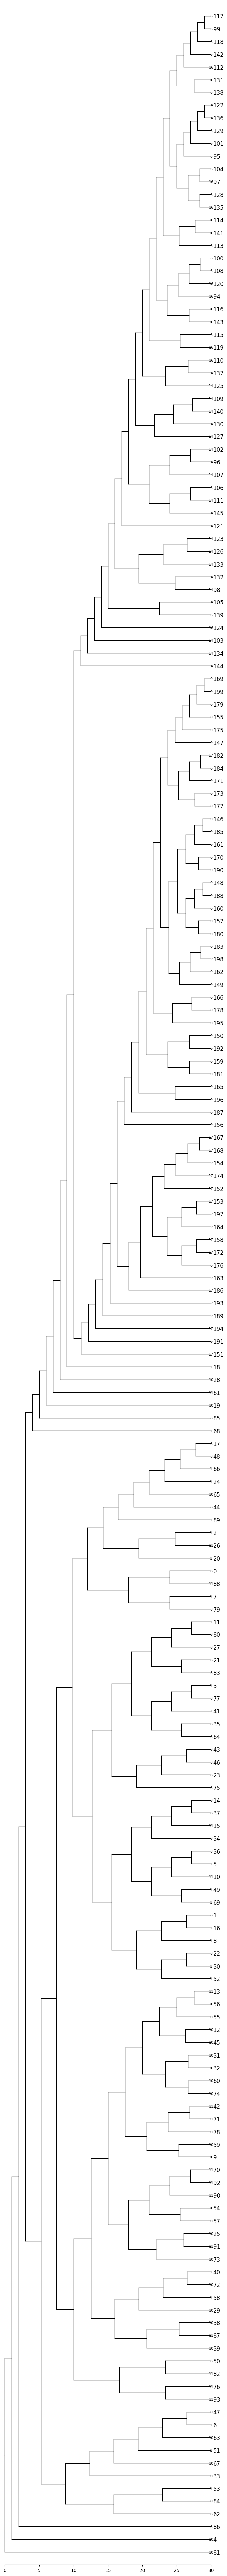

In [31]:
from phytreeviz import TreeViz # for tree visuaization

tv = TreeViz(tree.output())
traversor = popgen.utils.TraversalGenerator()
for node in traversor(tree):
    leaves = [leaf.name for leaf in node.get_leaves()]
    # tv.text_on_branch(leaves, node.cn, xpos='center', ypos='top', color='blue')


# tv.show_branch_length(color='red', label_formatter=lambda v: f"#mut: {v:.2f}")
# tv.show_confidence(color='blue', label_formatter=lambda v: f"conf: {v:.2f}")

for leaf in tree.get_leaves():
    leaf = tree[leaf]
    cell_id = cell_ids[int(leaf.name)]
    label = df_clone[df_clone['cell_id'] == cell_id]['clone_id'].values[0]
    tv.text_on_node(leaf.name, label)


tv.show_scale_axis()
fig = tv.plotfig()

In [11]:
n_cell = reads.shape[1]
n_site = reads.shape[0]
s = ScisTreeC(CN_MAX=9, CN_MIN=1, LAMBDA_C=100, LAMBDA_S=1, LAMBDA_T=2*n_cell-1, verbose=False)
probs = s.init_prob_leaves_gpu(reads, cnerr=0.05, af=0.5)
ml2, indices = s.marginal_evaluate_dp(probs, tree)
scistreec_geno = construct_genotype(tree, indices)
sites = [_ for _ in range(n_site)]
decoded_trees = s.viterbi_decoding(probs, tree, sites)
tt = find_copy_gain_loss_on_branch(decoded_trees) 

OutOfMemoryError: Out of memory allocating 8,305,152 bytes (allocated so far: 24,582,136,320 bytes).